In [10]:
# load data

import pandas as pd

df = pd.read_csv("../outputs/sample_size.csv")

In [11]:
summary = (
    df.groupby("n_samples")
    .agg(
        mean_r2 = ("r2", "mean"),
        sd_r2 = ("r2", "std"),
        mean_mse=("mse", "mean"),
        sd_mse=("mse", "std"),
    )
    .reset_index()
)

In [12]:
summary

,n_samples,mean_r2,sd_r2,mean_mse,sd_mse
0,1,-1.405153,2.400143,0.913450,0.911548
1,2,-1.044871,1.475007,0.776619,0.560191
2,4,-0.728426,0.846163,0.656437,0.321363
3,6,-0.644528,0.589129,0.624574,0.223745
4,10,-0.210092,0.381286,0.459580,0.144808
5,15,0.050027,0.204609,0.360789,0.077708
6,23,0.158207,0.165505,0.319704,0.062857
7,37,0.269824,0.118853,0.277313,0.045139
8,58,0.294710,0.071718,0.267861,0.027238
9,91,0.341386,0.060441,0.250134,0.022955


Text(0, 0.5, 'Mean MSE')

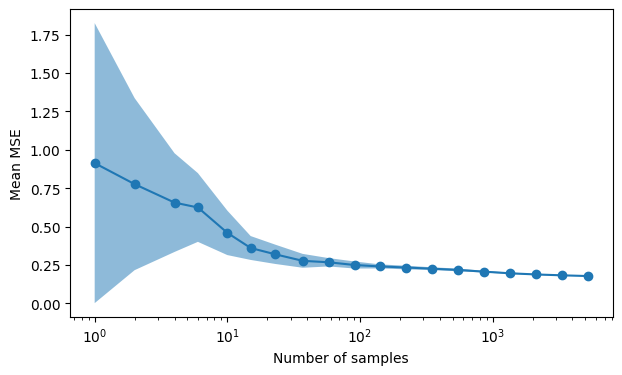

In [13]:
import matplotlib.pyplot as plt

x = summary['n_samples']
y = summary['mean_mse']
std = summary['sd_mse']

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, y, marker='o')
ax.fill_between(x, y - std, y + std, alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Mean MSE')

In [14]:
def power_law(n, C, alpha, epsilon):
    return C* n **(-alpha) + epsilon

In [15]:
from scipy.optimize import curve_fit

k = summary["n_samples"].values
mse = summary["mean_mse"].values

p0 = [
    max(mse) - min(mse),
    0.5,
    min(mse)
]

params, _ = curve_fit(power_law, k, mse, p0=p0, maxfev=10000)

C_hat, alpha_hat, epsilon_hat = params

Text(0, 0.5, 'Mean MSE')

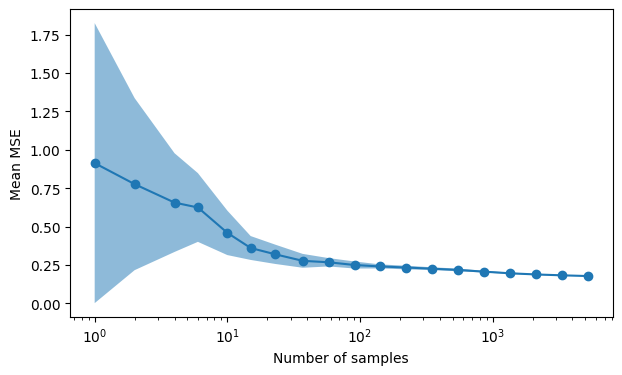

In [24]:
import matplotlib.pyplot as plt

x = summary['n_samples']
y = summary['mean_mse']
std = summary['sd_mse']

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, y, marker='o')
ax.fill_between(x, y - std, y + std, alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Mean MSE')

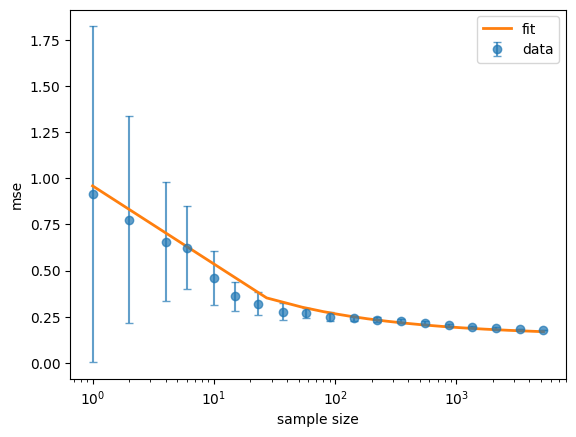

In [25]:
import numpy as np
import matplotlib.pyplot as plt

n_smooth = np.linspace(min(k), max(k), 200)


plt.errorbar(
    k,
    mse,
    yerr=std,
    fmt='o',
    capsize=3,
    alpha=0.7,
    label="data"
)

plt.plot(
    n_smooth,
    power_law(n_smooth, *params),
    lw=2,
    label="fit"
)

plt.xscale("log")
plt.xlabel("sample size")
plt.ylabel("mse")
plt.legend()
plt.show()

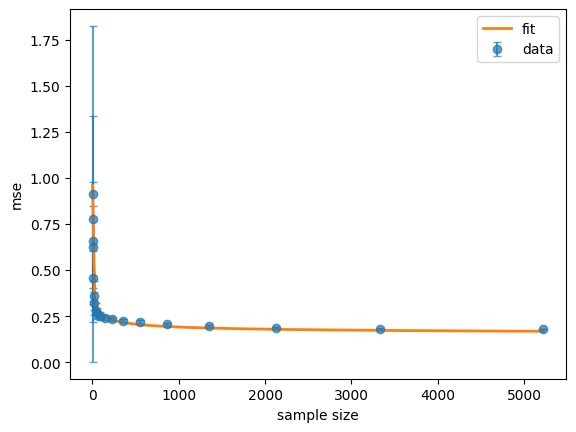

In [21]:

n_smooth = np.linspace(min(k), max(k), 200)


plt.errorbar(
    k,
    mse,
    yerr=std,
    fmt='o',
    capsize=3,
    alpha=0.7,
    label="data"
)

plt.plot(
    n_smooth,
    power_law(n_smooth, *params),
    lw=2,
    label="fit"
)

plt.xlabel("sample size")
plt.ylabel("mse")
plt.legend()
plt.show()

In [20]:
print(params)

[0.81445409 0.41519535 0.14491538]
